d:\software\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\software\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:52<00:00, 10.5MB/s] 


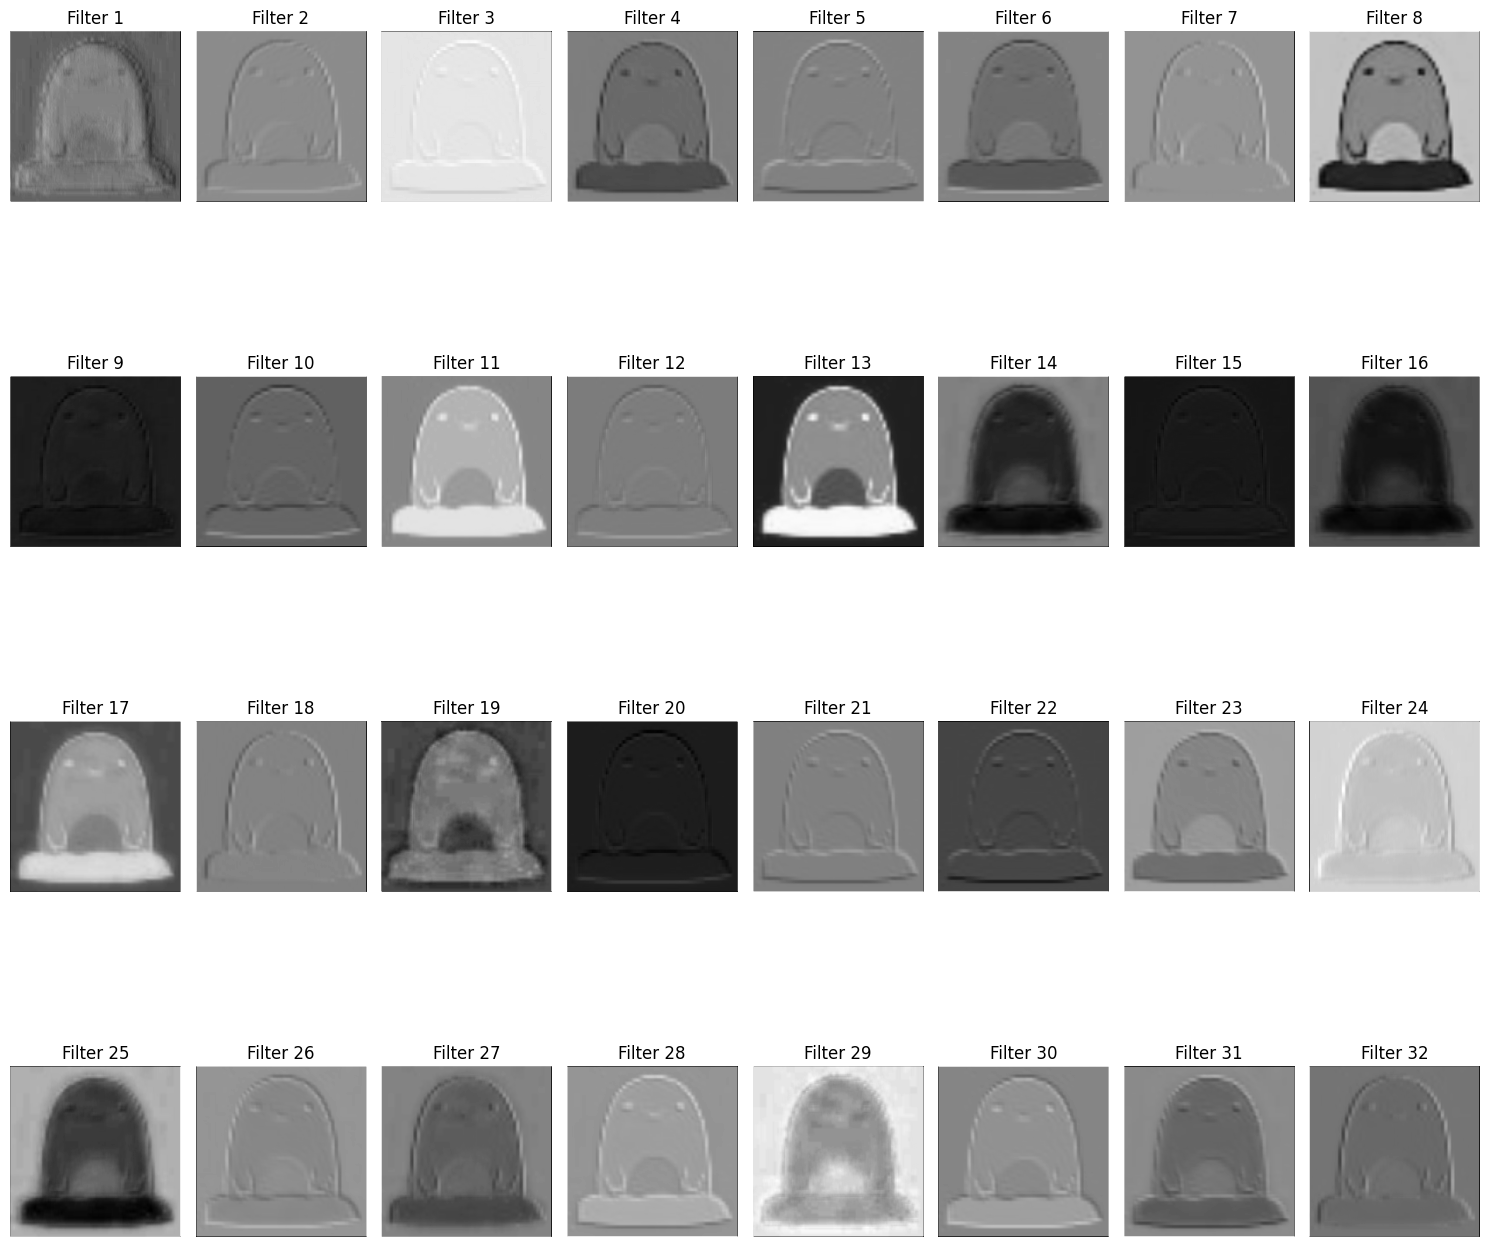

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

img_path = 'bird.jpg'
image = Image.open(img_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
input_tensor = transform(image).unsqueeze(0) 
model = models.vgg16(pretrained=True)
model.eval()

first_conv = model.features[0]

with torch.no_grad():
    feature_maps = first_conv(input_tensor)

# Plot the first 32 feature maps
plt.figure(figsize=(15, 15))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    plt.imshow(feature_maps[0, i].numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'Filter {i+1}')
plt.tight_layout()
plt.show()
